In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("../tissue_dataset.csv")
X = df.drop(columns = ["target", "target_actual"])
y = df["target"]

In [41]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(133, 1926)

In [42]:
#Cross Validation
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [43]:
#LASSO model
lasso_cv = LogisticRegressionCV(
    penalty = "l1",
    solver = "liblinear",
    cv = cv,
    scoring = "f1",
    max_iter = 5000, 
    random_state = 42
)
lasso_cv.fit(
    X_scaled,
    y
)

c:\Users\Z\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Z\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Z\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to 

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'f1'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme f

In [44]:
#Ranking list
coefficients = lasso_cv.coef_[0]

lasso_features = pd.DataFrame({
    "miRNA": X.columns,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
})

lasso_features = lasso_features[
    lasso_features["Coefficient"] != 0
]

lasso_features = lasso_features.sort_values(
    by = "Abs_Coefficient",
    ascending = False
)

lasso_features.reset_index(
    drop = True,
    inplace = True
)
lasso_features.insert(
    0,
    "Rank",
    range(1, len(lasso_features) + 1)
)

lasso_features["Direction"] = np.where(
    lasso_features["Coefficient"] > 0,
    "Cancer",
    "Normal"
)

lasso_features

,Rank,miRNA,Coefficient,Abs_Coefficient,Direction
0,1,147506 : hsa-miR-21-5p,0.590035,0.590035,Cancer
1,2,30787 : hsa-miR-125b-5p,-0.519288,0.519288,Normal
2,3,148387 : hsa-miR-3942-5p,-0.337743,0.337743,Normal
3,4,147904 : hsa-miR-3148,-0.258592,0.258592,Normal
4,5,147997 : hsa-miR-3934,-0.249747,0.249747,Normal
5,6,46361 : hsa-miR-1278,0.248701,0.248701,Cancer
6,7,145677 : hsa-miR-139-5p,-0.196513,0.196513,Normal
7,8,145824 : hsa-miR-509-3-5p,-0.178658,0.178658,Normal
8,9,169314 : hsa-miR-4668-3p,0.174090,0.174090,Cancer
9,10,148228 : hsa-miR-3656,-0.095064,0.095064,Normal


In [45]:
#Save Ranking list
lasso_features.to_csv(
    "../results/lasso_feature_ranking.csv",
    index=False
)

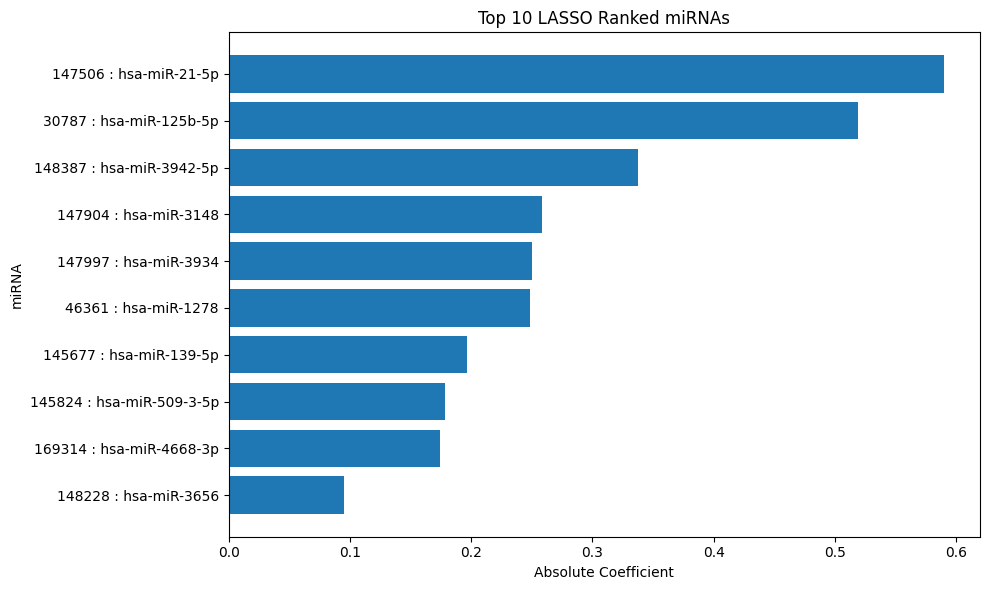

In [47]:
top10 = lasso_features.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["miRNA"],
    top10["Abs_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("miRNA")
plt.title("Top 10 LASSO Ranked miRNAs")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig(
    "../figures/Lasso_top10",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## LASSO Feature Ranking Summary

- Data: 133 samples, 1926 miRNAs
- Scaling: StandardScaler
- Model: L1-Regularized Logistic Regression
- Hyperparameter Selection: 5-Fold Stratified Cross-Validation
- Scoring Metric: F1 Score
- Optimal C: 0.359
- Selected Features: 17

### Key Observation
LASSO reduced the feature space from 1926 miRNAs to 17 candidate features. The highest-ranked miRNA was hsa-miR-21-5p, a well-known cancer-associated miRNA, providing biological support for the feature selection results.